In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/Krish AI/Solar Panel Classification"
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [ ]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [ ]:
class_names = train_dataset.class_names
num_classes = len(class_names)

In [ ]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [ ]:
num_classes

6

## Base Model (CNN2D)

In [ ]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Flattening
model.add(tf.keras.layers.Flatten())

# FCL
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 10

In [ ]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.2127 - loss: 2.5819 - val_accuracy: 0.3107 - val_loss: 1.7349
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.3654 - loss: 1.5939 - val_accuracy: 0.4576 - val_loss: 1.4821
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.5184 - loss: 1.3104 - val_accuracy: 0.5254 - val_loss: 1.3345
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 0.6419 - loss: 1.0192 - val_accuracy: 0.5819 - val_loss: 1.2383
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.7539 - loss: 0.7044 - val_accuracy: 0.5424 - val_loss: 1.3396
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.8640 - loss: 0.4211 - val_accuracy: 0.5706 - val_loss: 1.3809
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.9170 - loss: 0.2571 - val_accuracy: 0.5706 - val_loss: 1.8538
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.9400 - loss: 0.1566 - val_accuracy: 0.5650 - va

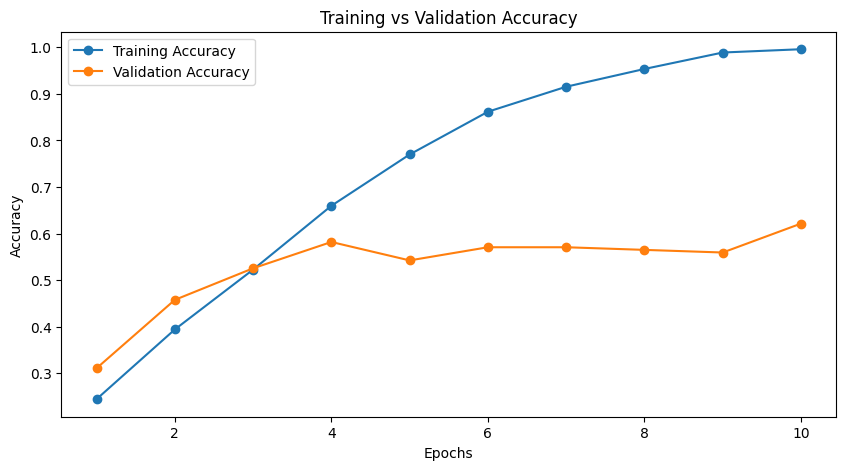

In [ ]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.9884 - loss: 0.0397 - val_accuracy: 0.5706 - val_loss: 2.0574
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 102s 4s/step - accuracy: 0.9897 - loss: 0.0546 - val_accuracy: 0.5819 - val_loss: 2.0676
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.9940 - loss: 0.0287 - val_accuracy: 0.6045 - val_loss: 1.9664
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 102s 4s/step - accuracy: 0.9888 - loss: 0.0529 - val_accuracy: 0.6158 - val_loss: 1.7767
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.9950 - loss: 0.0225 - val_accuracy: 0.6271 - val_loss: 2.0304
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 146s 4s/step - accuracy: 0.9980 - loss: 0.0136 - val_accuracy: 0.6215 - val_loss: 2.1586
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.9934 - loss: 0.0218 - val_accuracy: 0.6215 - val_loss: 1.7693
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.9916 - loss: 0.0208 - val_accuracy: 0.6328 - v

## Solve the Overfitting problem

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3)

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

def scheduler(epoch,lr):
  if epoch > 5:
    return lr*0.1
  return lr

lr_schedule = LearningRateScheduler(scheduler)

In [ ]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Flattening
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))

# FCL
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 10

In [ ]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 139s 6s/step - accuracy: 0.2845 - loss: 25.7296 - val_accuracy: 0.1186 - val_loss: 5.8220
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step - accuracy: 0.4809 - loss: 2.5145 - val_accuracy: 0.1695 - val_loss: 16.7249
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 0.6171 - loss: 1.2151 - val_accuracy: 0.1525 - val_loss: 20.1069
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.6597 - loss: 1.0460 - val_accuracy: 0.0452 - val_loss: 24.2745
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 136s 4s/step - accuracy: 0.7300 - loss: 0.7382 - val_accuracy: 0.1808 - val_loss: 15.4532
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.7431 - loss: 0.7751 - val_accuracy: 0.2429 - val_loss: 12.3501
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 105s 5s/step - accuracy: 0.7682 - loss: 0.6120 - val_accuracy: 0.2768 - val_loss: 8.3462
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.7701 - loss: 0.6512 - val_accuracy: 0.24

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom,
    Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [ ]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.15),
    # Optional: add RandomContrast(0.2) if colors vary a lot
])

## Grok.com's recommendation

In [ ]:


# -------------------------------
# Data Augmentation (Critical fix)
# -------------------------------


# -------------------------------
# Build the Model
# -------------------------------
model = tf.keras.models.Sequential()

# Input + Augmentation + Rescaling
model.add(data_augmentation)
model.add(Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Conv Block 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))  # Extra layer for better features
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.35))

# Classifier
model.add(Flatten())
# Alternative (often better): use GlobalAveragePooling2D() instead of Flatten()
# model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation="softmax"))

# -------------------------------
# Compile with lower initial LR
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # Reduced from default 1e-3
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# Callbacks
# -------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,           # More patient now that we have augmentation
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Halve LR when plateau
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# -------------------------------
# Train the model
# -------------------------------
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,  # Allow more epochs since early stopping will protect us
    callbacks=callbacks,
    verbose=1
)

# Optional: Print final results
print("\nTraining complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 290s 12s/step - accuracy: 0.2432 - loss: 3.2436 - val_accuracy: 0.0904 - val_loss: 3.5180 - learning_rate: 3.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 316s 12s/step - accuracy: 0.3715 - loss: 2.7390 - val_accuracy: 0.0904 - val_loss: 5.5095 - learning_rate: 3.0000e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 319s 12s/step - accuracy: 0.4776 - loss: 2.4514 - val_accuracy: 0.0904 - val_loss: 9.1453 - learning_rate: 3.0000e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.5126 - loss: 2.2639 
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
23/23 ━━━━━━━━━━━━━━━━━━━━ 276s 12s/step - accuracy: 0.5123 - loss: 2.2667 - val_accuracy: 0.0904 - val_loss: 9.7419 - learning_rate: 3.0000e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 264s 11s/step - accuracy: 0.4971 - loss: 2.4359 - val_accuracy: 0.0904 - val_loss: 10.3015 - learning_rate: 1.5000e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 253s 11s/step - accuracy: 0.529

## Insights so far

## Transfer Learning - MobileNetV2

In [ ]:
#MobileNetV2 base model

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [ ]:
base_model.trainable = False

model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)
model.add(tf.keras.layers.Rescaling(1.0/255))

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.3015 - loss: 2.0307 - val_accuracy: 0.5932 - val_loss: 1.1339
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5933 - loss: 1.0827 - val_accuracy: 0.5537 - val_loss: 1.0611
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.7044 - loss: 0.8076 - val_accuracy: 0.6271 - val_loss: 0.8905
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7594 - loss: 0.7203 - val_accuracy: 0.6554 - val_loss: 0.9244
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.7791 - loss: 0.6582 - val_accuracy: 0.6554 - val_loss: 0.9675
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8036 - loss: 0.6116 - val_accuracy: 0.7119 - val_loss: 0.8031
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8083 - loss: 0.5273 - val_accuracy: 0.5989 - val_loss: 1.0753
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8172 - loss: 0.4603 - val_accuracy: 0.6158 - val_loss:

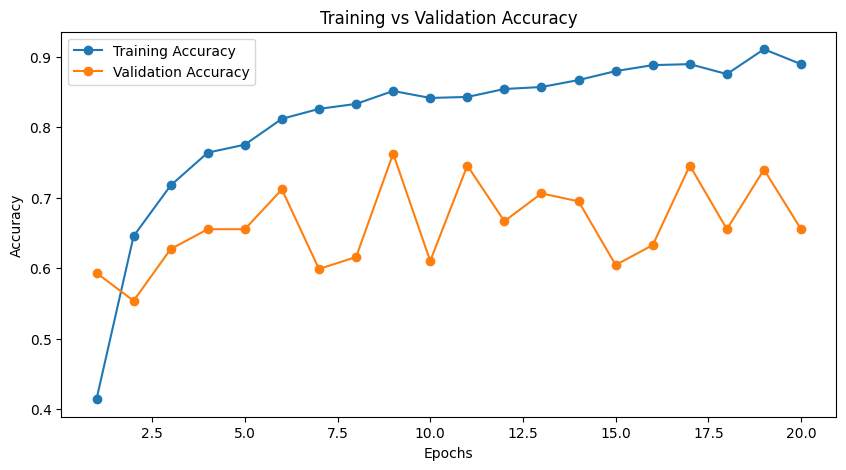

In [ ]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, 21)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/Krish AI/Solar Panel Classification/mobilenetv2_2.h5')

## EfficientNet

In [ ]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [ ]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [ ]:
class_names = train_dataset.class_names

In [ ]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [ ]:
num_classes = len(class_names)

In [ ]:
num_classes

6

In [ ]:
class_counts = {}
total_images = 0

for class_name in class_names:
  class_path = os.path.join(DATASET_DIR, class_name)
  count = len(os.listdir(class_path))
  class_counts[class_name] = count
  total_images += count

In [ ]:
class_weights = {}

for index, class_name in enumerate(class_names):
  class_weights[index] = total_images / (num_classes * class_counts[class_name])

print("Class weights", class_weights)

Class weights {0: 0.7530224525043178, 1: 0.7491408934707904, 2: 0.7649122807017544, 3: 1.4110032362459546, 4: 2.106280193236715, 5: 1.1815718157181572}


In [ ]:
data_augmentation = tf.keras.Sequential()
data_augmentation.add(tf.keras.layers.RandomFlip("horizontal"))
data_augmentation.add(tf.keras.layers.RandomRotation(0.1))
data_augmentation.add(tf.keras.layers.RandomZoom(0.1))

In [ ]:
train_images = []
train_labels = []

In [ ]:
for images, labels in train_dataset:
  images = preprocess_input(images)
  train_images.append(images)
  train_labels.append(labels)

In [ ]:
train_images = tf.concat(train_images, axis=0)
train_labels = tf.concat(train_labels, axis=0)

In [ ]:
validation_images = []
validation_labels = []

In [ ]:
for images, labels in validation_dataset:
  images = preprocess_input(images)
  validation_images.append(images)
  validation_labels.append(labels)

In [ ]:
validation_images = tf.concat(validation_images, axis=0)
validation_labels = tf.concat(validation_labels, axis=0)

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape = (224,224,3),
    include_top = False,
    weights="imagenet"
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 108s 4s/step - accuracy: 0.4535 - loss: 1.4108 - val_accuracy: 0.6384 - val_loss: 0.9960
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.7626 - loss: 0.7185 - val_accuracy: 0.7232 - val_loss: 0.7701
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.7908 - loss: 0.5914 - val_accuracy: 0.7006 - val_loss: 0.7677
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.8145 - loss: 0.5026 - val_accuracy: 0.7684 - val_loss: 0.6827
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.8505 - loss: 0.4751 - val_accuracy: 0.7740 - val_loss: 0.6613
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.8780 - loss: 0.3656 - val_accuracy: 0.8136 - val_loss: 0.6479
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.8834 - loss: 0.3357 - val_accuracy: 0.7571 - val_loss: 0.6360
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.9097 - loss: 0.2941 - val_accuracy: 0.7966 - val_loss

## Hyper Parameter Optimization

In [ ]:
!pip install keras-tuner  # Run if not installed

import keras_tuner as kt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Reuse your train_dataset and validation_dataset (with preprocess_input already applied)
# Make sure they are defined as in your original code

def build_model(hp):
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(hp.Float("rotation_factor", min_value=0.05, max_value=0.3, step=0.05)),
        RandomZoom(hp.Float("zoom_factor", min_value=0.05, max_value=0.3, step=0.05)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)),
        Dense(
            hp.Int("dense_units", min_value=64, max_value=512, step=64),
            activation='relu'
        ),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Setup Random Search Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,          # Same as n_iter before
    executions_per_trial=1,
    directory='kt_dir',
    project_name='efficientnet_tune',
    overwrite=True
)

# Optional: Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Run the search
tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights  # Handles imbalance
)

# Results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on validation
val_loss, val_acc = best_model.evaluate(validation_dataset)
print(f"Best validation accuracy: {val_acc:.4f}")

Trial 20 Complete [00h 15m 23s]
val_accuracy: 0.7796609997749329

Best val_accuracy So Far: 0.8305084705352783
Total elapsed time: 06h 49m 09s
Best hyperparameters:
{'rotation_factor': 0.05, 'zoom_factor': 0.05, 'dropout_rate': 0.4, 'dense_units': 128, 'learning_rate': 0.002910285815853156}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8578 - loss: 0.4483
Best validation accuracy: 0.8305


In [ ]:
best_model.save('/content/drive/MyDrive/Krish AI/Solar Panel Classification/trained_effnet_finetune.h5')